# Imports
Theory: Import libraries for data manipulation (pandas), visualization (seaborn/matplotlib), and modeling (scikit-learn).
Syntax: `import pandas as pd`, `from sklearn.model_selection import train_test_split`, etc.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset
Theory: Load the mushroom dataset from the `mushroom` folder and inspect rows, shape, and class balance.
Syntax: `pd.read_csv(path, encoding='unicode_escape')`; use `display(df.head())` and `df['class'].value_counts()` to inspect.

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


shape: (8124, 23)

class distribution:
 class
e    4208
p    3916
Name: count, dtype: int64


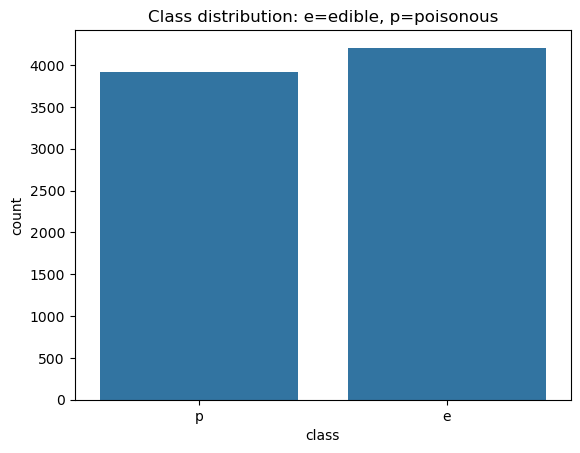

In [5]:
# adjust the path if your working directory differs
df = pd.read_csv('../mushroom/mushrooms.csv', encoding='unicode_escape')
display(df.head())
print('shape:', df.shape)
print('\nclass distribution:\n', df['class'].value_counts())
# quick visualization of class balance
sns.countplot(x='class', data=df)
plt.title('Class distribution: e=edible, p=poisonous')
plt.show()

# Preprocessing (one-hot encoding)
Theory: All features are categorical. One-hot encoding converts each category into binary indicator columns without implying an order.
Syntax: `pd.get_dummies(df, drop_first=False)` produces dummy/indicator variables.

In [6]:
# Separate features and target
df_features = df.drop('class', axis=1)
# One-hot encode all categorical columns
X = pd.get_dummies(df_features, drop_first=False)
X.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


# Target vector (y)
Theory: Map the class column (`e`/`p`) to numeric labels (0/1).
Syntax: `y = df['class'].map({'e':0, 'p':1})`

In [7]:
y = df['class'].map({'e': 0, 'p': 1})
y.value_counts()

class
0    4208
1    3916
Name: count, dtype: int64

# Train / Test split
Theory: Hold out a test set to evaluate generalization. Syntax: `train_test_split(X, y, test_size=..., random_state=...)`.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)
print('train shape:', X_train.shape, 'test shape:', X_test.shape)

train shape: (6499, 117) test shape: (1625, 117)


# Model definition
Theory: Logistic Regression is a linear classifier; with many one-hot features we may need to increase `max_iter`.
Syntax: `LogisticRegression(max_iter=500)` constructs the model.

In [9]:
model = LogisticRegression(max_iter=500)

# Train the model
Theory: Fit the model to the training data. Syntax: `model.fit(X_train, y_train)`

In [10]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


# Prediction
Theory: Predict labels on the test set with `model.predict(X_test)`.

In [11]:
y_pred = model.predict(X_test)

# Evaluation
Theory: Compute accuracy, confusion matrix, and a classification report to inspect precision/recall/f1.

In [12]:
print('Accuracy (model.score):', model.score(X_test, y_test))
print('Accuracy (sklearn):', accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
print('\nClassification report:\n', classification_report(y_test, y_pred))

Accuracy (model.score): 0.9987692307692307
Accuracy (sklearn): 0.9987692307692307
Confusion matrix:
 [[859   0]
 [  2 764]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       859
           1       1.00      1.00      1.00       766

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

